# Spatiotemporal LSTM Autoencoder for Video Anomaly Detection
This notebook implements the sequence-to-sequence temporal modeling segment of the project.
It loads the pre-extracted spatial features (128-dimensional latent vectors) generated by the 2D CNN block, passing continuous sliding window tensors into an LSTM Autoencoder.

**Core Directives enforced:**
1. Sequence-to-Sequence standard LSTM Autoencoder architecture.
2. Mathematically strict evaluation where Anomaly = Deviation from Normal (Higher Reconstruction MSE).
3. Optimization bounds mapped across continuous timeline chronologies.

In [88]:
%pip install scikit-learn

/Users/adel/Projects/Deep learning/DL project2/Danger_Recognition/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [89]:
# Step 1: Data Loading & Validation Split
import numpy as np
import os

print("--- Step 1: Data Loading & Split ---")
# 1. Load the pre-engineered windowed tensors
# Paths in my owen environment so change accoridng to yours.
train_path = 'X_train_sequences.npy'
test_path = 'X_test_sequences.npy'

if not os.path.exists(train_path) or not os.path.exists(test_path):
    raise FileNotFoundError("Missing sequence NumPy files. Ensure 'spatial_pipeline.ipynb' completed successfully.")

X_train_sequences = np.load(train_path)
X_test_sequences = np.load(test_path)

# 2. Chronological Validation Split (80/20) - strictly sequential, no shuffling to fix the leak issue in time-series data
split_idx = int(len(X_train_sequences) * 0.8)
X_train_fit = X_train_sequences[:split_idx]
X_val = X_train_sequences[split_idx:]

print(f"Loaded X_train_sequences: {X_train_sequences.shape}")
print(f"Loaded X_test_sequences:  {X_test_sequences.shape}\n")
print("80/20 Chronological Training Split Executed:")
print(f" -> X_train_fit (Training set):   {X_train_fit.shape}")
print(f" -> X_val (Validation for early stopping): {X_val.shape}")

--- Step 1: Data Loading & Split ---
Loaded X_train_sequences: (3588, 10, 128)
Loaded X_test_sequences:  (5122, 10, 128)

80/20 Chronological Training Split Executed:
 -> X_train_fit (Training set):   (2870, 10, 128)
 -> X_val (Validation for early stopping): (718, 10, 128)


In [90]:
# Step 2: LSTM Autoencoder Architecture
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

print("\n--- Step 2: LSTM Autoencoder Initialization ---")

# Define Sequence Constraints based on input topology
seq_length = 10
feature_dim = 128

# Sequence-to-Sequence standard LSTM Autoencoder framework
lstm_autoencoder = Sequential([
    # Inputs: (batch_size, sequence_length, feature_dimension) -> (batch_size, 10, 128)
    Input(shape=(seq_length, feature_dim), name="Temporal_Input"),
    
    #  ENCODER 
    # Step down mapping temporal behaviors into an increasingly restrictive latent vector representation
    LSTM(64, activation='tanh', return_sequences=True, name="Encoder_LSTM_1"),
    LSTM(32, activation='tanh', return_sequences=False, name="Encoder_Bottleneck"),
    
    #  BOTTLENECK  
    # Holds temporal representations mapped down strictly to a 32 dimension wide hidden state
    # Replicates this fixed state across the output timeline requirement (10 repetitions)
    RepeatVector(seq_length, name="Bridge_Repeater"),
    
    #  DECODER  
    # Expands latent representation identically structured reversed
    LSTM(32, activation='tanh', return_sequences=True, name="Decoder_LSTM_1"),
    LSTM(64, activation='tanh', return_sequences=True, name="Decoder_LSTM_2"),
    
    # Evaluates every temporal tick along the sequence dynamically reconstructing independent flat arrays explicitly backward to 128 parameters
    TimeDistributed(Dense(feature_dim), name="Reconstruction_Output")
], name="SpatioTemporal_Autoencoder")

# Compile targeting baseline physical deviations 
lstm_autoencoder.compile(optimizer='adam', loss='mse')
lstm_autoencoder.summary()

# Training Execution Parameters
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

print("\nExecuting Unsupervised Autoencoder Training Pass...")
history = lstm_autoencoder.fit(
    X_train_fit, X_train_fit, # Input ==  target for Autoencoders
    epochs=50,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping],
    verbose=1
)


--- Step 2: LSTM Autoencoder Initialization ---
Model: "SpatioTemporal_Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Encoder_LSTM_1 (LSTM)       (None, 10, 64)            49408     
                                                                 
 Encoder_Bottleneck (LSTM)   (None, 32)                12416     
                                                                 
 Bridge_Repeater (RepeatVec  (None, 10, 32)            0         
 tor)                                                            
                                                                 
 Decoder_LSTM_1 (LSTM)       (None, 10, 32)            8320      
                                                                 
 Decoder_LSTM_2 (LSTM)       (None, 10, 64)            24832     
                                                                 
 Reconstruction_Output (Tim  (None, 10, 128)           83

2026-05-19 21:03:01.536963: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:01.779964: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:01.837780: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:01.894739: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:01.947250: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:02.045906: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:02.133606: I tensorflow/core/grappler/optimizers/cust

 4/45 [=>............................] - ETA: 0s - loss: 2.0396e-04  

2026-05-19 21:03:02.313848: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


45/45 [==============================] - ETA: 0s - loss: 4.3145e-05

2026-05-19 21:03:03.296408: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:03.361289: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:03.400155: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:03.439964: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:03.471438: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


45/45 [==============================] - 3s 28ms/step - loss: 4.3145e-05 - val_loss: 4.4554e-06
Epoch 2/50
45/45 [==============================] - 1s 12ms/step - loss: 2.2560e-06 - val_loss: 1.8789e-06
Epoch 3/50
45/45 [==============================] - 1s 12ms/step - loss: 9.8006e-07 - val_loss: 1.3853e-06
Epoch 4/50
45/45 [==============================] - 0s 11ms/step - loss: 6.1810e-07 - val_loss: 1.1695e-06
Epoch 5/50
45/45 [==============================] - 1s 12ms/step - loss: 4.4912e-07 - val_loss: 1.0439e-06
Epoch 6/50
45/45 [==============================] - 1s 12ms/step - loss: 3.5317e-07 - val_loss: 9.7756e-07
Epoch 7/50
45/45 [==============================] - 1s 12ms/step - loss: 2.9301e-07 - val_loss: 9.4181e-07
Epoch 8/50
45/45 [==============================] - 1s 12ms/step - loss: 2.5240e-07 - val_loss: 9.0433e-07
Epoch 9/50
45/45 [==============================] - 1s 12ms/step - loss: 2.2382e-07 - val_loss: 8.9026e-07
Epoch 10/50
45/45 [=============================

In [91]:
# Step 3: Threshold Calibration
print("\n--- Step 3: Threshold Calibration ---")

# 1. Generate reconstructions on unseen validation data
val_reconstructions = lstm_autoencoder.predict(X_val, verbose=0)

# 2. Calculate MSE for validation sequences
val_mse = np.mean(np.square(X_val - val_reconstructions), axis=(1, 2))

# 3. Calculate baseline statistics
mean_val_mse = np.mean(val_mse)
std_val_mse = np.std(val_mse)

# 4. Define the anomaly threshold (Mean + 1 Std Deviation)
threshold = mean_val_mse + (1 * std_val_mse)

print(f"Calibration Complete: Threshold set at {threshold:.8f}")


--- Step 3: Threshold Calibration ---


2026-05-19 21:03:15.874093: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:15.926494: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:15.953557: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:15.982940: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-19 21:03:16.015874: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Calibration Complete: Threshold set at 0.00000134


In [92]:
# Step 4: Evaluation on the Full Test Set
print("\n--- Step 4: Evaluation on the Continuous Narrative Stream (Full Test Set) ---")

# 1. Forward reconstruct the full test stream matrix parameters
test_reconstructions = lstm_autoencoder.predict(X_test_sequences, verbose=0)

# 2. Calculate testing specific absolute deviation arrays on the full set
test_mse_per_sequence = np.mean(np.square(X_test_sequences - test_reconstructions), axis=(1, 2))

# 3. Calculate True Anomaly Score (Absolute Deviation from Baseline)
test_anomaly_scores = np.abs(test_mse_per_sequence - mean_val_mse)

print(f"Total Test Sequences Evaluated: {len(X_test_sequences)}")


--- Step 4: Evaluation on the Continuous Narrative Stream (Full Test Set) ---
Total Test Sequences Evaluated: 5122


In [93]:
# Step 5: Ground Truth Alignment and Metrics
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

print("\n--- Step 5: Ground Truth Compilation & Metric Analysis ---")

# Load Real Ground Truth Targets
# Assumes the labels were processed from XML and saved as 'y_true_binary.npy'
y_true_binary = np.load('y_true_binary.npy')
# 

# Export Area Under the ROC Curve for the full test set using deviation scores
roc_auc = roc_auc_score(y_true_binary, test_anomaly_scores)
print(f"Full ROC AUC Score Evaluated: {roc_auc:.4f}")


--- Step 5: Ground Truth Compilation & Metric Analysis ---
Full ROC AUC Score Evaluated: 0.4434


In [94]:
# Step 6: Optimal Threshold Calibration (Youden's J Statistic) on Full Data
from sklearn.metrics import roc_curve, classification_report
import numpy as np

# 1. Calculate FPR, TPR, and thresholds using the ROC curve on the anomaly scores
fpr, tpr, thresholds = roc_curve(y_true_binary, test_anomaly_scores)

# 2. Calculate Youden's J statistic (TPR - FPR) to balance Precision and Recall
youden_j = tpr - fpr

# 3. Find the index of the maximum J statistic and extract the optimal threshold
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimized Alarm Threshold (Absolute Deviation): {optimal_threshold:e}")

# 4. Generate new binary predictions based on the optimal threshold
# 1 = Anomaly (Deviation > threshold), 0 = Normal
y_pred_optimal = (test_anomaly_scores > optimal_threshold).astype(int)

# 5. Output updated classification metrics evaluating the entire test slice
print("\nFull Classification Report (Optimized for Recall & Precision Balance):")
print(classification_report(y_true_binary, y_pred_optimal, target_names=["Normal Sequence (0)", "Anomaly Threat (1)"], zero_division=0))

Optimized Alarm Threshold (Absolute Deviation): 4.503802e-07

Full Classification Report (Optimized for Recall & Precision Balance):
                     precision    recall  f1-score   support

Normal Sequence (0)       0.24      0.19      0.21      1089
 Anomaly Threat (1)       0.79      0.84      0.82      4033

           accuracy                           0.70      5122
          macro avg       0.52      0.51      0.51      5122
       weighted avg       0.68      0.70      0.69      5122




--- Plotting Continuous Anomaly Scores vs. Threshold ---


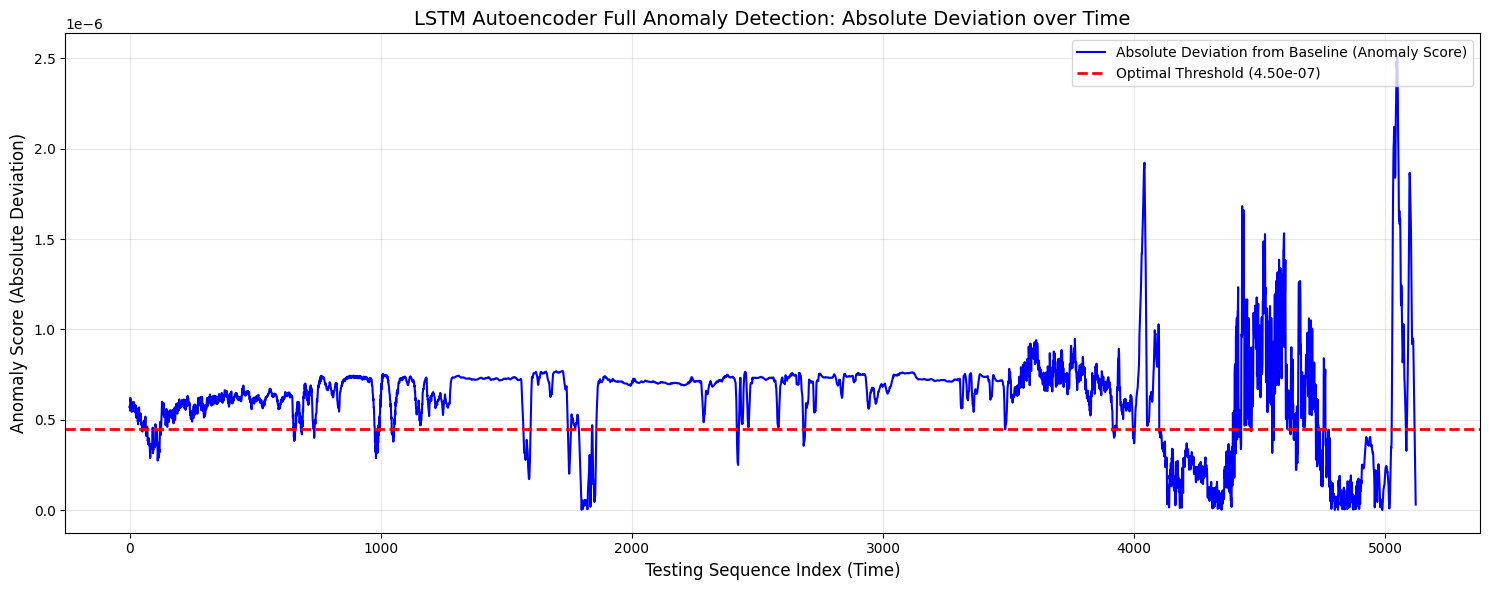

In [95]:
# Step 7: Visualizing Full Anomaly Detection
import matplotlib.pyplot as plt

print("\n--- Plotting Continuous Anomaly Scores vs. Threshold ---")

plt.figure(figsize=(15, 6))

# Plot the continuous sequence anomaly scores for the full set in blue
plt.plot(test_anomaly_scores, color='blue', label='Absolute Deviation from Baseline (Anomaly Score)')

# Plot the mathematically optimal threshold as a red horizontal line
plt.axhline(y=optimal_threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Optimal Threshold ({optimal_threshold:.2e})')

plt.title('LSTM Autoencoder Full Anomaly Detection: Absolute Deviation over Time', fontsize=14)
plt.xlabel('Testing Sequence Index (Time)', fontsize=12)
plt.ylabel('Anomaly Score (Absolute Deviation)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()


--- Visualizing the Full Confusion Matrix ---


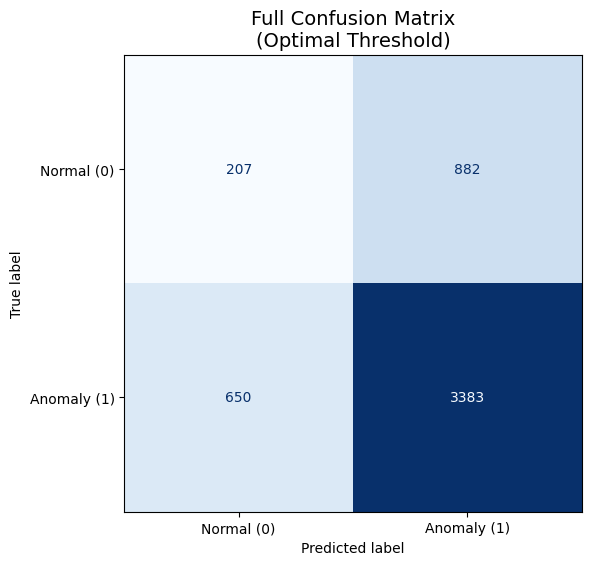

In [96]:
# Step 8: Full Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n--- Visualizing the Full Confusion Matrix ---")

# Compute the confusion matrix using the dynamically optimized predictions
cm = confusion_matrix(y_true_binary, y_pred_optimal)

# Configure the plot display
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Anomaly (1)"])

# Plot with a clean colormap and precise formatting
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', colorbar=False)

plt.title('Full Confusion Matrix\n(Optimal Threshold)', fontsize=14)
plt.tight_layout()

# Display the matrix
plt.show()